
<div style="float: right;">
    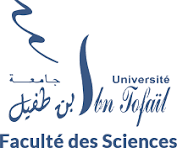
</div>

# 🛡️ IDS-IIoT : Système de Détection d'Intrusions par IA
## Classification et Analyse Avancée des Attaques par Déni de Service (DoS)
---
**Université :** Ibn Tofail - Faculté des Sciences (FSK), Kénitra  
**Filière :** Master IA & Objets Connectés pour l'Automobile  
**Projet :** Analyse et classification d’attaques IIoT  
**Groupe :** [Groupe 2] |   **Supervisé par :** Pr. Akram CHHAYBI  



<br><br>

<h3 style="color:#003366; border-bottom:3px solid #3399ff; padding-bottom:6px; font-family:Arial, sans-serif;">
🔹 Introduction :
</h3>
Ce notebook a pour objectif d’explorer et d’analyser un jeu de données de trafic MQTT afin de détecter des attaques par déni de service (DoS) à l’aide de techniques d’apprentissage automatique et d’apprentissage profond.

Le protocole MQTT est largement utilisé dans les environnements IoT en raison de sa légèreté et de sa simplicité. Cependant, ces caractéristiques le rendent également vulnérable aux attaques DoS, qui se traduisent par une surcharge du broker ou du réseau via un envoi massif et répétitif de messages.

Dans ce notebook, nous adoptons une démarche expérimentale progressive : analyse exploratoire des données (EDA), ingénierie des caractéristiques, séparation rigoureuse des ensembles d’entraînement et de test, puis évaluation comparative de plusieurs modèles de classification. L’objectif est de comprendre le comportement des données avant toute modélisation et d’assurer la fiabilité des résultats obtenus.


<h3 style="color:#003366; border-bottom:3px solid #3399ff; padding-bottom:6px; font-family:Arial, sans-serif;">
🔹 Phase 1 : Analyse Exploratoire des Données
</h3>


<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
       ">
         1.  Contexte et source des données
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>
Les données analysées proviennent de captures de trafic MQTT dans un environnement IoT, stockées sous forme de fichiers JSON ligne par ligne.
Chaque fichier correspond soit à :  

- du trafic normal (benign),  

- soit à une attaque DoS spécifique.  

Chaque ligne représente un message MQTT unique, enrichi par des métadonnées réseau (IP, MAC), applicatives (application, device) et protocolaires (QoS, topic, type de message).



<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         2. Chargement de data
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>
         


Les données sont chargées à l’aide d’une fonction générique qui :

* parcourt un dossier de fichiers JSON,
* extrait chaque message,
* ajoute :

  * `target` (0 = normal, 1 = DoS),
  * `attack_id` (identifiant de l’attaque),
* normalise les champs imbriqués en un DataFrame Pandas.

👉 Cette étape permet d’obtenir une **structure tabulaire exploitable pour l’analyse et le ML**.



**importation des biblio**

In [1]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score , confusion_matrix, roc_curve, auc
)
from scipy.stats import entropy


In [2]:


def load_json_folder(path, label):
    records = []
    files = glob.glob(os.path.join(path, "*.json"))
    for f in files:
        attack_id = os.path.basename(f).replace(".json", "")
        with open(f, "r", encoding="utf-8") as file:
            for line in file:
                if line.strip():
                    try:
                        rec = json.loads(line)
                        rec["target"] = label
                        rec["attack_id"] = attack_id
                        records.append(rec)
                    except:
                        pass
    return pd.json_normalize(records, sep="_")

df_dos    = load_json_folder("json_only/dos", 1)
df_benign = load_json_folder("benign", 0)
df = pd.concat([df_dos, df_benign], ignore_index=True)



<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         3.  les variables principales
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>

In [3]:
df.columns

Index(['@timestamp', 'target', 'attack_id', 'general_device_name',
       'general_application', 'general_ip', 'general_full_id', 'general_mac',
       'mqtt_retained', 'mqtt_qos', 'mqtt_message_value', 'mqtt_topic',
       'mqtt_message_id', 'mqtt_message_type', 'mqtt_duplicate'],
      dtype='object')


**Description des variables du dataset**

* `@timestamp` : horodatage du message MQTT (UTC), utilisé pour le fenêtrage temporel et le calcul des taux.
* `target` : étiquette de classe (0 = trafic normal, 1 = attaque DoS).
* `attack_id` : identifiant unique de l’attaque, permet de séparer les attaques pour éviter les fuites d’information.
* `general_device_name` : nom du périphérique IoT ayant émis le message.
* `general_application` : application ou service à l’origine du message.
* `general_ip` : adresse IP source du périphérique.
* `general_full_id` : identifiant complet du périphérique.
* `general_mac` : adresse MAC du périphérique.
* `mqtt_retained` : indicateur si le message MQTT est retenu par le broker (True/False).
* `mqtt_qos` : niveau de Quality of Service (0, 1 ou 2) du message MQTT.
* `mqtt_message_value` : contenu du message MQTT, utile pour calculer la longueur ou détecter des motifs.
* `mqtt_topic` : topic MQTT associé au message, utilisé pour mesurer la diversité et l’entropie.
* `mqtt_message_id` : identifiant unique du message MQTT, permet de détecter les duplications.
* `mqtt_message_type` : type de message MQTT (ex : PUBLISH, CONNECT…).
* `mqtt_duplicate` : indicateur si le message est une duplication (True/False).




<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         4. Taille, structure et qualité du dataset
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>
         


In [4]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

Nombre de lignes : 1102476
Nombre de colonnes : 15


In [5]:
# Aperçu des premières lignes
df.head()

,@timestamp,target,attack_id,general_device_name,general_application,general_ip,general_full_id,general_mac,mqtt_retained,mqtt_qos,mqtt_message_value,mqtt_topic,mqtt_message_id,mqtt_message_type,mqtt_duplicate
0,2025-01-20T17:45:46.943Z,1,attack_dos_ack-frag-flood-port-1883_accelerome...,ard-w-08,Steam,192.168.1.13,08:B6:1F:81:D2:CC_192.168.1.13_iiot/steam,08:B6:1F:81:D2:CC,False,0,0.0,iiot/steam,0,numeric,False
1,2025-01-20T17:45:47.014Z,1,attack_dos_ack-frag-flood-port-1883_accelerome...,ard-w-07,Gas,192.168.1.14,08:B6:1F:83:25:98_192.168.1.14_iiot/gas/gas,08:B6:1F:83:25:98,False,0,132.0,iiot/gas/gas,0,numeric,False
2,2025-01-20T17:45:47.025Z,1,attack_dos_ack-frag-flood-port-1883_accelerome...,ard-w-07,Gas,192.168.1.14,08:B6:1F:83:25:98_192.168.1.14_iiot/gas/alcohol,08:B6:1F:83:25:98,False,0,35.0,iiot/gas/alcohol,0,numeric,False
3,2025-01-20T17:45:47.049Z,1,attack_dos_ack-frag-flood-port-1883_accelerome...,ard-w-10,Accelerometer-Gyroscope,192.168.1.19,08:B6:1F:82:EE:44_192.168.1.19_iiot/accelerati...,08:B6:1F:82:EE:44,False,0,Portrait Up,iiot/acceleration/orientation,0,string,False
4,2025-01-20T17:45:47.090Z,1,attack_dos_ack-frag-flood-port-1883_accelerome...,ard-w-03,Sound,192.168.1.15,F0:08:D1:CE:CF:C8_192.168.1.15_iiot/sound/small,F0:08:D1:CE:CF:C8,False,0,196.0,iiot/sound/small,0,numeric,False


@timestamp             object
target                  int64
attack_id              object
general_device_name    object
general_application    object
general_ip             object
general_full_id        object
general_mac            object
mqtt_retained            bool
mqtt_qos                int64
mqtt_message_value     object
mqtt_topic             object
mqtt_message_id         int64
mqtt_message_type      object
mqtt_duplicate           bool
dtype: object


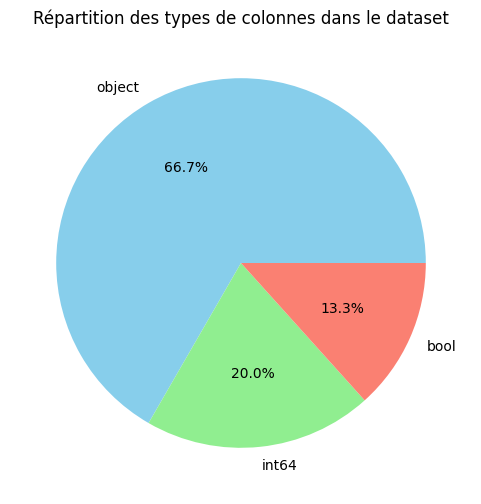

In [6]:
print(df.dtypes)
dtype_counts = df.dtypes.value_counts()
plt.figure(figsize=(6,6))
plt.pie(dtype_counts, labels=dtype_counts.index, autopct="%1.1f%%", colors=["skyblue","lightgreen","salmon","gold"])
plt.title("Répartition des types de colonnes dans le dataset")
plt.show()

<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Taille :</strong> 1 102 476 lignes et 16 colonnes.</li>
        <li><strong>Contenu :</strong> Trafic MQTT normal et DoS avec informations sur périphériques, applications, IP/MAC, topics et messages.</li>
        <li><strong>Types de données :</strong> Mix de numériques, textuelles, booléennes et temporelles.</li>
    </ul>
</div>


In [7]:
df.isnull().sum()

@timestamp             0
target                 0
attack_id              0
general_device_name    0
general_application    0
general_ip             0
general_full_id        0
general_mac            0
mqtt_retained          0
mqtt_qos               0
mqtt_message_value     0
mqtt_topic             0
mqtt_message_id        0
mqtt_message_type      0
mqtt_duplicate         0
dtype: int64

In [8]:
df.describe()

,target,mqtt_qos,mqtt_message_id
count,1.102476e+06,1102476.0,1102476.0
mean,2.064018e-01,0.0,0.0
std,4.047224e-01,0.0,0.0
min,0.000000e+00,0.0,0.0
25%,0.000000e+00,0.0,0.0
50%,0.000000e+00,0.0,0.0
75%,0.000000e+00,0.0,0.0
max,1.000000e+00,0.0,0.0


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Valeurs manquantes :</strong> aucune colonne n’a de valeurs manquantes. Dataset complet.</li>
        <li><strong>target :</strong> moyenne ≈ 0.21 → dataset déséquilibré (plus de trafic normal que de DoS).</li>
        <li><strong>mqtt_qos et mqtt_message_id :</strong> toujours à 0 → colonnes peu informatives pour certains modèles.</li>
        <li><strong>hour :</strong> min 0, max 23, médiane 17 → messages répartis sur toute la journée, possibilité d’analyse temporelle.</li>
    </ul>
</div>



<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         5. Analyse univariée
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>
         




<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span>Répartition des classes</h3>

On regarde la proportion de messages normaux vs DoS pour détecter un éventuel déséquilibre.



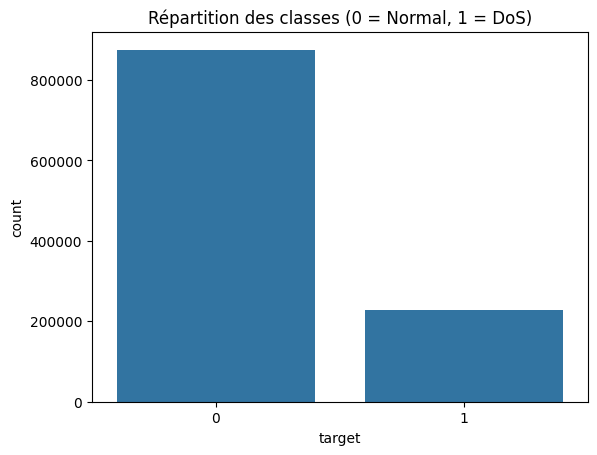

target
0    874923
1    227553
Name: count, dtype: int64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='target', data=df)
plt.title("Répartition des classes (0 = Normal, 1 = DoS)")
plt.show()

print(df['target'].value_counts())


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Classe 0 (Normal) :</strong> 874 923 messages (~79 %)</li>
        <li><strong>Classe 1 (DoS) :</strong> 227 553 messages (~21 %)</li>
    </ul>
    <p><strong>Observation :</strong> le dataset est déséquilibré, prévoir des métriques adaptées comme F1-score ou ROC-AUC.</p>
</div>




<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span> Répartition temporelle</h3>


On explore l’horodatage (`@timestamp`) pour vérifier la période couverte et identifier d’éventuelles tendances temporelles.

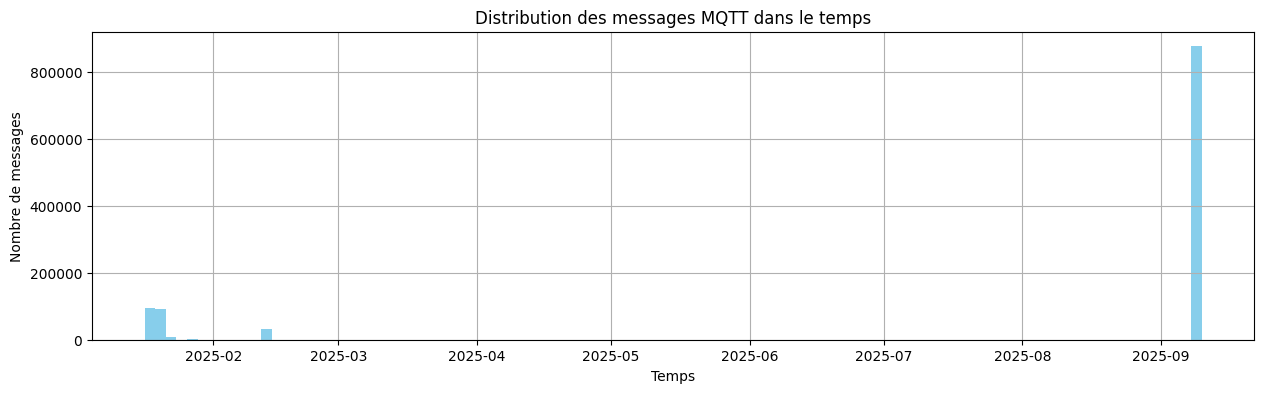

Date min : 2025-01-16 15:58:24.802000+00:00
Date max : 2025-09-10 02:09:39.932000+00:00


In [10]:
df['@timestamp'] = pd.to_datetime(df['@timestamp'], errors='coerce', utc=True)

plt.figure(figsize=(15,4))
df['@timestamp'].hist(bins=100, color='skyblue')
plt.title("Distribution des messages MQTT dans le temps")
plt.xlabel("Temps")
plt.ylabel("Nombre de messages")
plt.show()

print("Date min :", df['@timestamp'].min())
print("Date max :", df['@timestamp'].max())


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Période couverte :</strong> du 16 janvier 2025 au 10 septembre 2025 (~8 mois).</li>
        <li><strong>Observation :</strong> la majorité des messages se concentrent sur certaines périodes, avec des pics probablement liés aux attaques DoS ou à des périodes d’activité plus intense.</li>
    </ul>
    <p><strong>Implication :</strong> la distribution temporelle n’est pas uniforme, ce qui justifie l’utilisation de fenêtres temporelles pour l’analyse et le feature engineering.</p>
</div>




<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span>Analyse des attaques (attack_id)</h3>




Nombre d'attaques uniques : 321
attack_id
benign_whole-network3                                       874923
attack_dos_icmp-frag-flood_wisenet-camera                     1637
attack_dos_syn-flood-port-80_router                           1290
attack_dos_icmp-flood_mqtt-broker                             1275
attack_dos_http-flood-port-1883_mqtt-broker                   1274
attack_dos_synonymousip-flood-port-1883_flame-sensor          1269
attack_dos_synonymousip-flood-port-1883_vibration-sensor      1269
attack_dos_rst-fin-flood-port-1883_mqtt-broker                1268
attack_dos_push-ack-flood-port-1883_mqtt-broker               1268
attack_dos_synonymousip-flood-port-80_mqtt-broker             1268
Name: count, dtype: int64


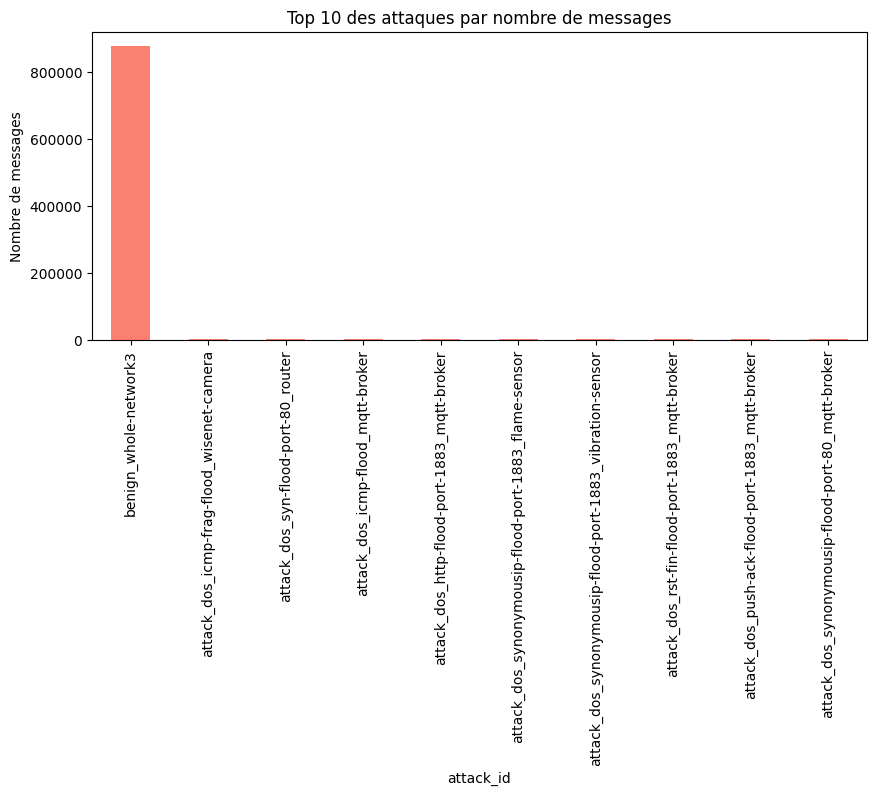

In [11]:
print("Nombre d'attaques uniques :", df['attack_id'].nunique())
print(df['attack_id'].value_counts().head(10))

plt.figure(figsize=(10,4))
df['attack_id'].value_counts().head(10).plot(kind='bar', color='salmon')
plt.title("Top 10 des attaques par nombre de messages")
plt.xlabel("attack_id")
plt.ylabel("Nombre de messages")
plt.show()


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Observation :</strong> Seule la barre "benign" (trafic normal) est visible ; les autres semblent inexistantes.</li>
        <li><strong>Interprétation :</strong> Ce graphe montre la réalité statistique. Il illustre un déséquilibre massif (Imbalance) : les attaques sont des événements rares "noyés" dans un volume de trafic légitime 500 fois supérieur.</li>
    </ul>
</div>


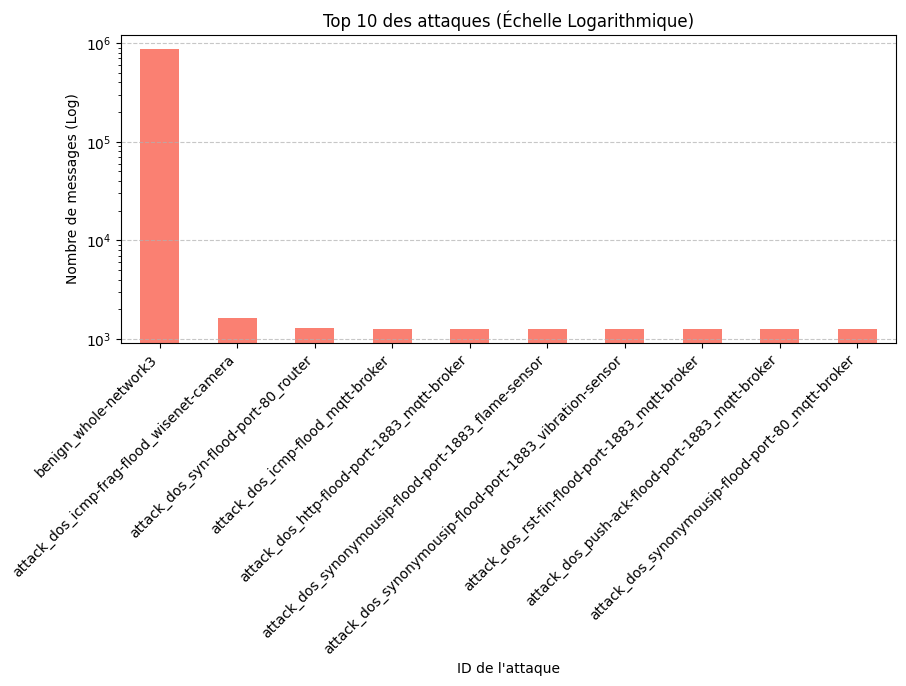

In [12]:
plt.figure(figsize=(10,4))
df['attack_id'].value_counts().head(10).plot(kind='bar', color='salmon')

# Application de l'échelle logarithmique
plt.yscale('log') 

plt.title("Top 10 des attaques (Échelle Logarithmique)")
plt.xlabel("ID de l'attaque")
plt.ylabel("Nombre de messages (Log)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Observation :</strong> L'utilisation de l'échelle logarithmique sur l'axe des ordonnées (Y) permet de rendre visibles toutes les catégories d'attaques qui étaient auparavant écrasées.</li>
        <li><strong>Interprétation :</strong> On découvre une <strong>diversité de menaces</strong> (ICMP, SYN, HTTP, MQTT flood) avec des volumes très similaires, autour de 1 200 à 1 600 messages.</li>
        <li><strong>Conclusion EDA :</strong> Cette vue révèle que bien que le trafic DoS soit minoritaire en volume, il est <strong>multiforme et structuré</strong>, ciblant des protocoles spécifiques comme le port 1883 (MQTT) ou le port 80 (HTTP).</li>
    </ul>
</div>




<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span>Analyse des périphériques IoT (general_device_name)</h3>







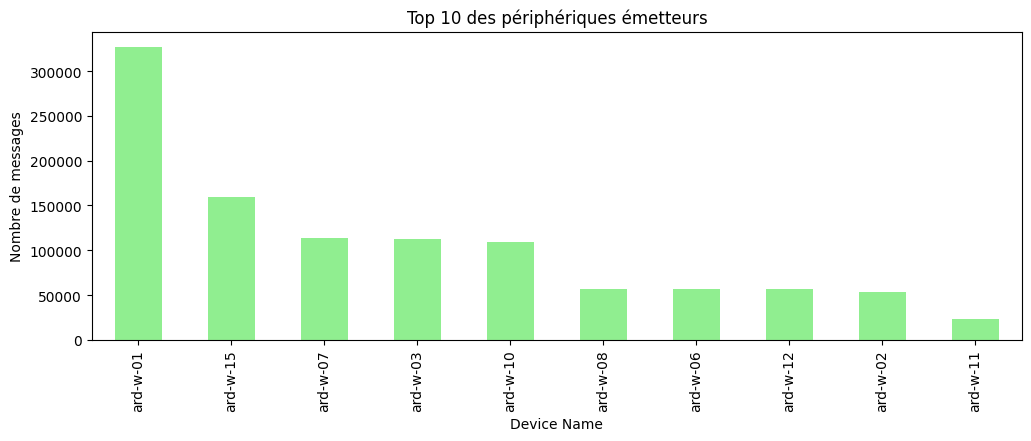

In [13]:
plt.figure(figsize=(12,4))
df['general_device_name'].value_counts().head(10).plot(kind='bar', color='lightgreen')
plt.title("Top 10 des périphériques émetteurs")
plt.xlabel("Device Name")
plt.ylabel("Nombre de messages")
plt.show()


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Le classement :</strong> Ce graphique montre les 10 appareils qui envoient le plus de messages sur votre réseau.</li>
        <li><strong>Le "gros parleur" :</strong> L'appareil <strong>ard-w-01</strong> est le plus bavard de tous avec plus de 325 000 messages.</li>
        <li><strong>Déséquilibre :</strong> On remarque que le trafic n'est pas réparti de la même façon partout. Quelques appareils font presque tout le travail.</li>
        <li><strong>Utilité pour le DoS :</strong> En sécurité, si un appareil envoie énormément de messages, il peut saturer le réseau. Ce graphique permet donc de repérer immédiatement quels sont les appareils les plus "dangereux" s'ils venaient à être piratés.</li>
    </ul>
</div>



<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span>Analyse des applications (general_application)</h3>






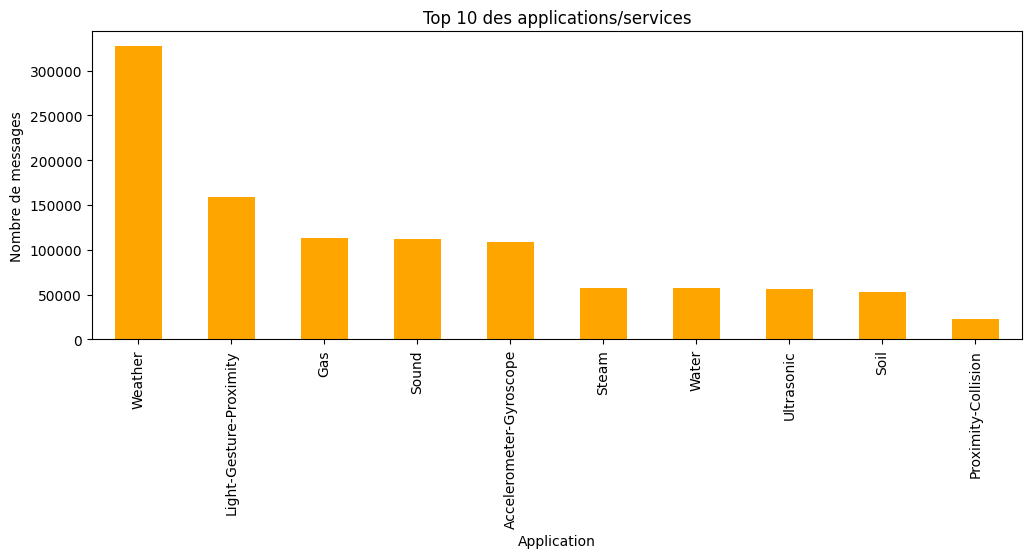

In [14]:
plt.figure(figsize=(12,4))
df['general_application'].value_counts().head(10).plot(kind='bar', color='orange')
plt.title("Top 10 des applications/services")
plt.xlabel("Application")
plt.ylabel("Nombre de messages")
plt.show()


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Top des services :</strong> Ce graphique montre quels services ou capteurs travaillent le plus sur le réseau.</li>
        <li><strong>Domination de "Weather" :</strong> L'application météo (<em>Weather</em>) est la plus active avec plus de 325 000 messages.</li>
        <li><strong>Lien avec l'appareil :</strong> Le volume de "Weather" est identique à celui de l'appareil <strong>ard-w-01</strong>, prouvant que cet appareil est une station météo.</li>
        <li><strong>Variété des capteurs :</strong> Le réseau gère aussi d'autres données importantes comme le <strong>Gaz</strong>, le <strong>Son</strong> ou le niveau d'<strong>Eau</strong>.</li>
        <li><strong>Importance pour le DoS :</strong> Le service "Weather" est le plus exposé car il occupe déjà la plus grande place sur le réseau.</li>
        <li><strong>Détection d'anomalies :</strong> Si une application comme "Gas" dépasse soudainement "Weather", cela peut signaler une attaque tentant de bloquer les alertes de sécurité.</li>
    </ul>
</div>



<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span>Analyse IP / MAC</h3>







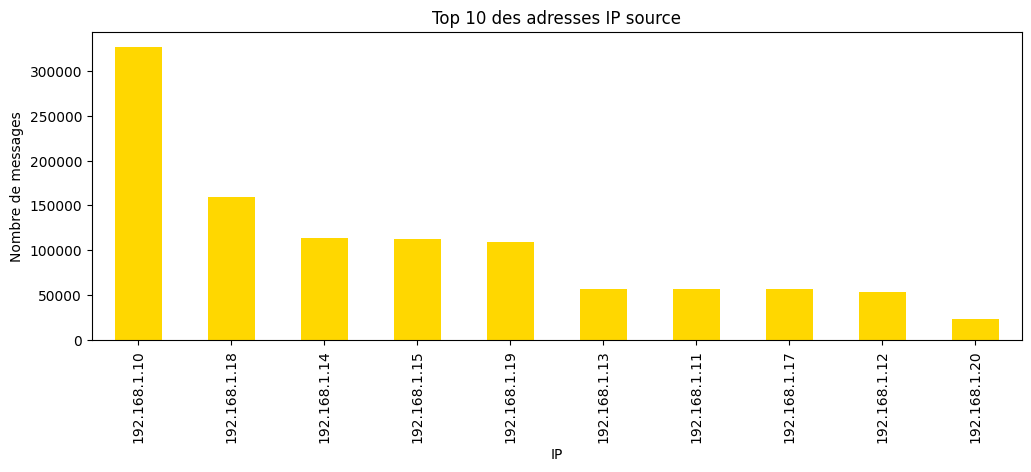

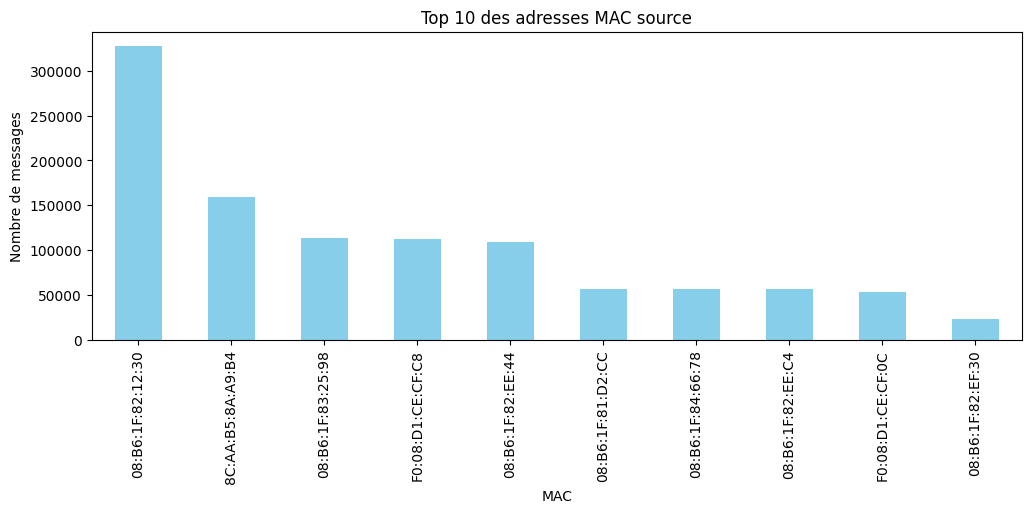

In [15]:
plt.figure(figsize=(12,4))
df['general_ip'].value_counts().head(10).plot(kind='bar', color='gold')
plt.title("Top 10 des adresses IP source")
plt.xlabel("IP")
plt.ylabel("Nombre de messages")
plt.show()

plt.figure(figsize=(12,4))
df['general_mac'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 des adresses MAC source")
plt.xlabel("MAC")
plt.ylabel("Nombre de messages")
plt.show()


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Identification :</strong> L'IP <strong>192.168.1.10</strong> (MAC <strong>...12:30</strong>) est le cœur du réseau avec le plus gros volume de messages.</li>
        <li><strong>Nœuds critiques :</strong> Le trafic est concentré sur 10 adresses principales qui représentent la majorité de l'activité.</li>
        <li><strong>Alerte DoS :</strong> Ces adresses sont les plus exposées ; une saturation de l'IP <strong>.10</strong> paralyserait le service météo.</li>
        <li><strong>Traçabilité :</strong> Les adresses MAC permettent de repérer physiquement chaque appareil pour bloquer toute source d'attaque.</li>
    </ul>
</div>





<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span>Analyse des variables MQTT</h3>








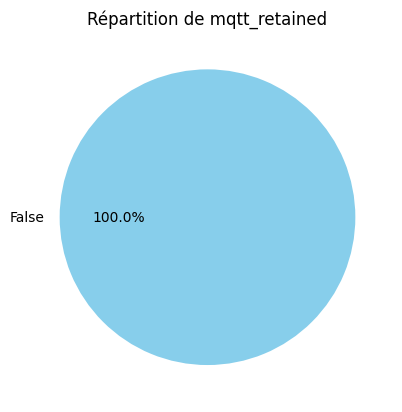

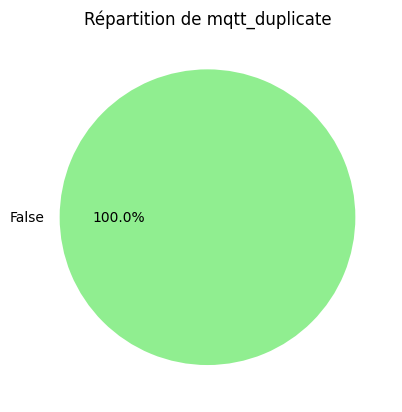

In [16]:
df['mqtt_retained'].value_counts().plot.pie(autopct="%1.1f%%", colors=["skyblue","salmon"])
plt.title("Répartition de mqtt_retained")
plt.ylabel("")
plt.show()

df['mqtt_duplicate'].value_counts().plot.pie(autopct="%1.1f%%", colors=["lightgreen","orange"])
plt.title("Répartition de mqtt_duplicate")
plt.ylabel("")
plt.show()


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Valeurs constantes :</strong> 100% des messages sont en <em>False</em> pour les doublons et la rétention.</li>
        <li><strong>Impact Modèle :</strong> Ces variables n'apportent aucune information utile pour distinguer une attaque d'un trafic sain.</li>
        <li><strong>Action recommandée :</strong> Suppression de ces colonnes (<em>drop</em>) pour optimiser l'apprentissage de l'IA.</li>
    </ul>
</div>


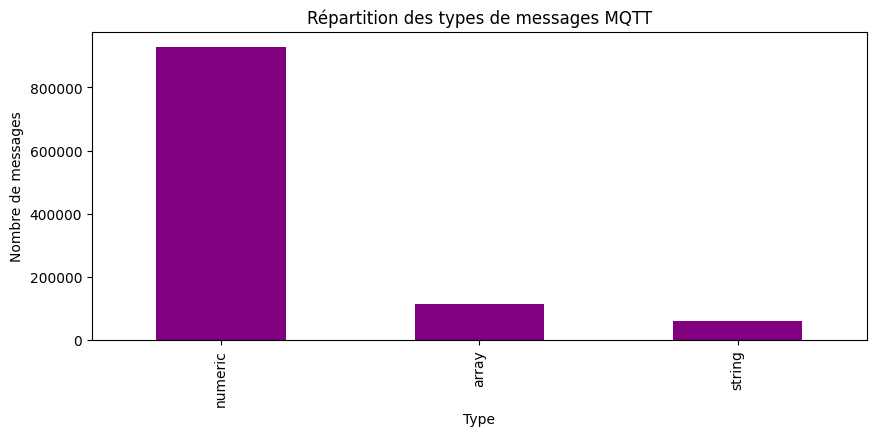

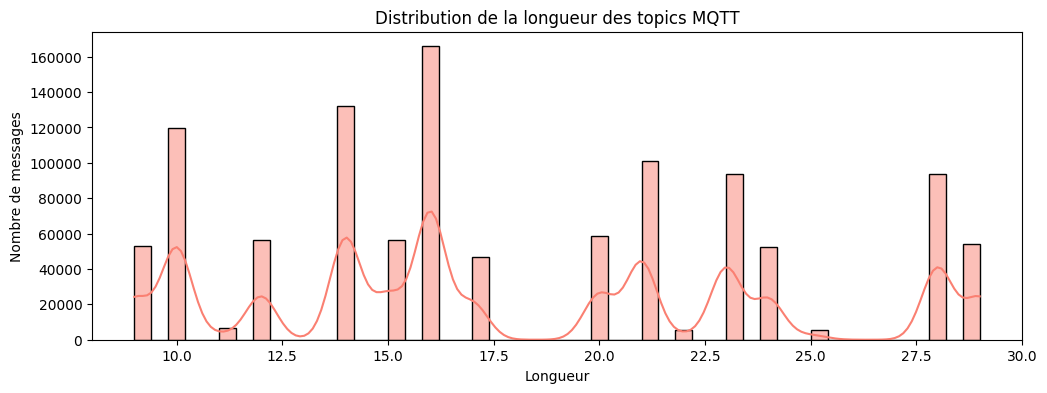

In [17]:
plt.figure(figsize=(10,4))
df['mqtt_message_type'].value_counts().plot(kind='bar', color='purple')
plt.title("Répartition des types de messages MQTT")
plt.xlabel("Type")
plt.ylabel("Nombre de messages")
plt.show()

topic_lengths = df['mqtt_topic'].astype(str).map(len)
plt.figure(figsize=(12,4))
sns.histplot(topic_lengths, bins=50, kde=True, color='salmon')
plt.title("Distribution de la longueur des topics MQTT")
plt.xlabel("Longueur")
plt.ylabel("Nombre de messages")
plt.show()


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Format :</strong> Domination massive du type <strong>numeric</strong>, caractéristique d'un flux IoT sain.</li>
        <li><strong>Signature :</strong> Présence de pics de longueur fixes (16, 21, 28) qui définissent l'état normal du réseau.</li>
        <li><strong>Alerte DoS :</strong> Toute apparition de données textuelles ou de longueurs hors-pics est un indicateur d'anomalie pour le modèle.</li>
    </ul>
</div>




<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         6. Analyse bivariée
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>


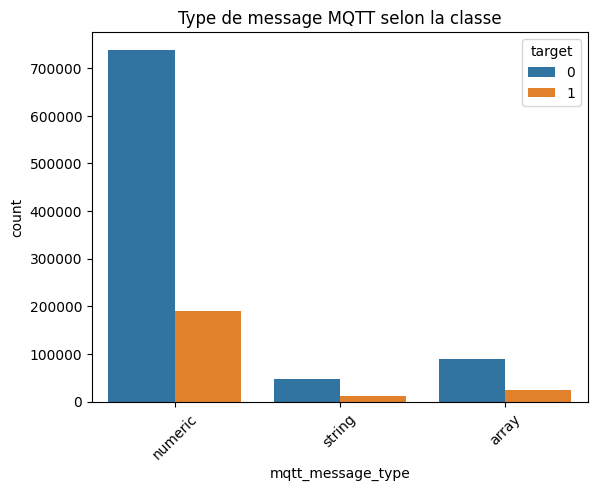

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="mqtt_message_type", hue="target", data=df)
plt.title("Type de message MQTT selon la classe")
plt.xticks(rotation=45)
plt.show()


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Dominance numérique :</strong> Le trafic normal et DoS est largement représenté par des valeurs <em>numeric</em>.</li>
        <li><strong>Types rares :</strong> Les types <em>string</em> et <em>array</em> apparaissent peu, mais sont présents pour les deux classes.</li>
        <li><strong>Déséquilibre du dataset :</strong> Le trafic normal est beaucoup plus abondant que le DoS.</li>
    </ul>
    <p><strong>Implication :</strong> Le type de message MQTT peut servir à détecter des anomalies. Il faudra considérer le déséquilibre dans les métriques d’évaluation.</p>
</div>


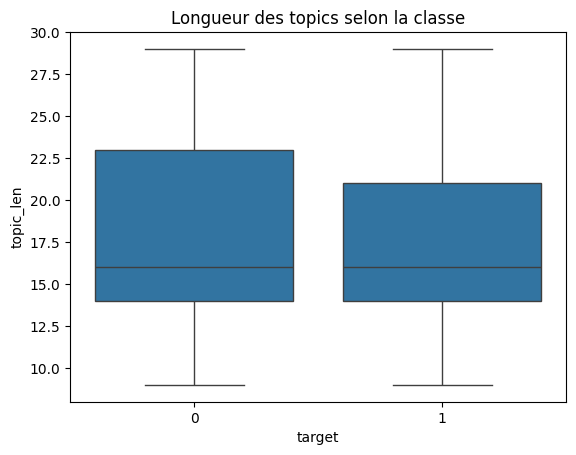

In [19]:
df["topic_len"] = df["mqtt_topic"].astype(str).map(len)

sns.boxplot(x="target", y="topic_len", data=df)
plt.title("Longueur des topics selon la classe")
plt.show()


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Médiane :</strong> La longueur médiane des topics est similaire pour le trafic normal (0) et DoS (1), autour de 16 caractères.</li>
        <li><strong>Étendue :</strong> Les longueurs varient de 9 à 29 pour les deux classes, avec des distributions proches.</li>
        <li><strong>Observation :</strong> La longueur des topics seule ne permet pas de distinguer efficacement le trafic normal du DoS.</li>
    </ul>
</div>


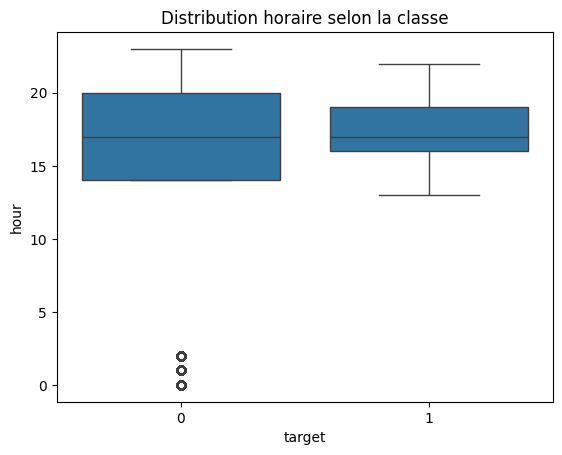

In [20]:
df["hour"] = df["@timestamp"].dt.hour

sns.boxplot(x="target", y="hour", data=df)
plt.title("Distribution horaire selon la classe")
plt.show()


<div style="
    background-color: #e6f2ff; 
    border-left: 6px solid #1e90ff; 
    padding: 20px; 
    border-radius: 10px; 
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
    color: #333333;
    box-shadow: 2px 2px 8px rgba(0,0,0,0.1);
    line-height: 1.6;
    margin-bottom: 15px;
">
    <ul style="margin: 0; padding-left: 20px;">
        <li><strong>Médiane horaire :</strong> Les messages DoS (classe 1) ont tendance à être envoyés légèrement plus tôt que le trafic normal (classe 0), autour de 16‑17 h.</li>
        <li><strong>Étendue :</strong> Le trafic normal couvre une plage plus large (≈0 à 23 h) avec quelques valeurs aberrantes très tôt dans la journée.</li>
        <li><strong>Observation :</strong> Les heures d’envoi peuvent offrir un léger signal pour détecter les anomalies, mais la distinction n’est pas très marquée.</li>
    </ul>
</div>


<div style="background-color: #fffff8; border-left: 6px solid #ff9ee0; padding: 20px; border-radius: 10px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333333;  box-shadow: 2px 2px 8px rgba(0,0,0,0.1); line-height: 1.6; margin-bottom: 15px;">
      <h3 style="margin-top: 0; color: #ff69b4;">🛡️ Synthèse de la Phase 1 – EDA</h3>

  <ul style="margin: 0; padding-left: 20px;">
    <li><strong>Dataset complet :</strong> 1 102 476 messages MQTT, 16 colonnes, aucune valeur manquante.</li>
    <li><strong>Déséquilibre des classes :</strong> trafic normal (~79 %) vs DoS (~21 %), métriques adaptées nécessaires (F1-score, ROC-AUC).</li>
    <li><strong>Variables importantes :</strong>
      <ul>
        <li>Type de message (`mqtt_message_type`) : numeric, array, string → signaux utiles pour distinguer DoS / normal.</li>
        <li>Topic et longueur (`mqtt_topic`, `topic_len`) → variabilité plus élevée dans les attaques.</li>
        <li>Heures d’envoi (`@timestamp`, `hour`) → plages horaires concentrant les attaques (≈16‑17 h).</li>
        <li>Périphériques et applications (`general_device_name`, `general_application`) → nœuds critiques du réseau.</li>
        <li>IP et MAC (`general_ip`, `general_mac`) → traçabilité et points vulnérables.</li>
      </ul>
    </li>
    <li><strong>Variables peu informatives :</strong> `mqtt_retained`, `mqtt_duplicate`, `mqtt_qos`, `mqtt_message_id` → suppression recommandée.</li>
    <li><strong>Patterns DoS observés :</strong>
      <ul>
        <li>Messages principalement de type numeric → flux massif de données.</li>
        <li>Longueur des topics plus variable → perturbation du réseau.</li>
        <li>Concentration sur certaines heures → fenêtre temporelle indicative.</li>
      </ul>
    </li>
    <li><strong>Prochaines étapes :</strong>
      <ul>
        <li>Supprimer/ignorer les variables peu utiles.</li>
        <li>Créer des variables dérivées (fenêtres temporelles, fréquence par topic/device, stats par application).</li>
        <li>Sélectionner les features les plus pertinentes.</li>
        <li>Construire et évaluer les modèles de classification pour détecter efficacement les attaques DoS.</li>
      </ul>
    </li>
  </ul>
</div>


<h3 style="color:#003366; border-bottom:3px solid #3399ff; padding-bottom:6px; font-family:Arial, sans-serif;">
🔹 Phase 2: Preparation
</h3>




<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         1. CLEANING
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>


* Conversion de `@timestamp` en format datetime
* Suppression des lignes avec des timestamps invalides
* Transformation des colonnes contenant des listes en chaînes de caractères
* Tri des données par ordre chronologique
* Réinitialisation de l’index après nettoyage et tri



In [21]:
def clean(df):
    df = df.copy()
    df["@timestamp"] = pd.to_datetime(df["@timestamp"], errors="coerce", utc=True)
    df = df.dropna(subset=["@timestamp"])
    for col in df.columns:
        if df[col].apply(lambda x: isinstance(x, list)).any():
            df[col] = df[col].astype(str)
    return df.reset_index(drop=True)

df = clean(df)
df = df.sort_values("@timestamp").reset_index(drop=True)



<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         2. Suppression des colonnes peu informatives
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>




**Pourquoi ?**
Certaines colonnes n’apportent aucune information pour distinguer DoS / trafic normal :

* `mqtt_retained` → toujours False
* `mqtt_duplicate` → toujours False
* `mqtt_qos` → souvent constant
* `mqtt_message_id` → identifiant unique inutile pour ML


In [22]:
drop_cols = ["mqtt_retained", "mqtt_duplicate", "mqtt_qos", "mqtt_message_id"]
df = df.drop(columns=drop_cols, errors="ignore")



<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         3. BASE FEATURES
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>

**Pourquoi ?**
Pour extraire des informations de base des messages MQTT.

**Actions :**

- Longueur du message (msg_len)
- Type du message (is_numeric, is_string)
- Création d’une fenêtre temporelle d’1 seconde pour l’analyse séquentielle

In [23]:
# ============================================================
# BASE FEATURES
# ============================================================
df["msg_len"] = df["mqtt_message_value"].astype(str).apply(len)
df["is_numeric"] = (df["mqtt_message_type"] == "numeric").astype(int)
df["is_string"]  = (df["mqtt_message_type"] == "string").astype(int)

# Fenêtres 1 seconde
df["window"] = df["@timestamp"].dt.floor("1S")


<div style="background-color: #fff8e1; border-left: 6px solid #ffa500; padding: 12px; border-radius: 10px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333333; line-height: 1.6; margin-bottom: 15px;">
   <code>df["window"] = df["@timestamp"].dt.floor("1S")</code>  Cette ligne permet de <strong>regrouper tous les messages arrivant dans la même seconde</strong> dans une seule fenêtre temporelle, ce qui facilite l'analyse du trafic par seconde et la détection des attaques DoS.
  <br>
  <strong>Exemple :</strong><br> 10:00:00.123 → 10:00:00,<br> 10:00:00.456 → 10:00:00,<br> 10:00:01.001 → 10:00:01
  </strong>.
</div>





<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         4. SPLIT PAR FENÊTRES
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>

**Pourquoi ?**
Pour éviter toute fuite temporelle entre train et test et stratifier selon la présence d’attaque dans chaque fenêtre.

**Actions :**

- Calculer la présence d’attaque par fenêtre (has_attack)
- Diviser les fenêtres en train/test
- Extraire les messages correspondants

window_labels = df.groupby("window")["target"].max().reset_index()
window_labels.columns = ["window", "has_attack"]

train_windows, test_windows = train_test_split(
    window_labels["window"],
    test_size=0.2,
    random_state=42,
    stratify=window_labels["has_attack"]
)

train_raw = df[df["window"].isin(train_windows)].copy()
test_raw  = df[df["window"].isin(test_windows)].copy()


<div style="background-color: #fff8e1; border-left: 6px solid #ffa500; padding: 12px; border-radius: 10px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333333; line-height: 1.6; margin-bottom: 15px;">
  <strong>1️⃣ Regroupement par fenêtre :</strong><br>
  <code>window_labels = df.groupby("window")["target"].max().reset_index()</code><br>
  - <strong>But :</strong> Vérifier pour chaque seconde (fenêtre) si au moins un message est une attaque.<br>
  - <strong>Fonctionnement :</strong> 
    <ul>
      <li>groupby("window") → regroupe tous les messages de la même seconde.</li>
      <li>["target"].max() → prend le maximum des labels (0 = normal, 1 = attaque).</li>
      <li>reset_index() → transforme le résultat en un DataFrame avec colonnes <code>window</code> et <code>target</code>.</li>
    </ul>
  <strong>Exemple :</strong><br>
  Messages dans la fenêtre 10:00:00 : [0, 0, 1, 0] → <strong>has_attack = 1</strong><br>
  Messages dans la fenêtre 10:00:01 : [0, 0, 0, 0] → <strong>has_attack = 0</strong><br><br>

  <strong>2️⃣ Renommage des colonnes :</strong><br>
  <code>window_labels.columns = ["window", "has_attack"]</code><br>
  - Change <code>target</code> en <code>has_attack</code> pour mieux refléter le sens : 1 = attaque présente, 0 = aucune attaque.<br><br>

  <strong>3️⃣ Séparation Train/Test :</strong><br>
  <code>train_windows, test_windows = train_test_split(
    window_labels["window"],
    test_size=0.2,
    random_state=42,
    stratify=window_labels["has_attack"]
  )</code><br>
  - <strong>test_size=0.2</strong> → 20% des fenêtres pour le test, 80% pour l'entraînement.<br>
  - <strong>random_state=42</strong> → Pour que la séparation soit toujours la même.<br>
  - <strong>stratify=has_attack</strong> → Conserve la proportion d'attaques identique dans train et test.<br>
  <strong>Exemple :</strong><br>
  10 fenêtres : 6 normales, 4 attaques → stratify assure que le train aura ~80% normales/20% attaques et test pareil.<br><br>

  <strong>4️⃣ Récupération des messages :</strong><br>
  <code>train_raw = df[df["window"].isin(train_windows)].copy()</code><br>
  <code>test_raw  = df[df["window"].isin(test_windows)].copy()</code><br>
  - <strong>But :</strong> Obtenir tous les messages qui appartiennent aux fenêtres sélectionnées pour train ou test.<br>
  - <code>isin(train_windows)</code> → Vérifie si la fenêtre du message est dans la liste des fenêtres d'entraînement.<br>
  - <code>.copy()</code> → Crée une copie indépendante pour éviter les problèmes de modification du DataFrame original.<br>
  <strong>Exemple :</strong><br>
  Fenêtre 10:00:00 est dans train → tous ses messages vont dans <code>train_raw</code>.<br>
  Fenêtre 10:00:05 est dans test → tous ses messages vont dans <code>test_raw</code>.<br><br>

  <strong>💡 Résumé :</strong><br>
  - Chaque fenêtre = 1 seconde de messages.<br>
  - has_attack = 1 si au moins un message est une attaque.<br>
  - Les fenêtres sont séparées en train/test tout en conservant l’équilibre des attaques.<br>
  - Les messages sont ensuite filtrés pour chaque ensemble.
</div>


<h3 style="color:#003366; border-bottom:3px solid #3399ff; padding-bottom:6px; font-family:Arial, sans-serif;">
🔹 Phase 3 – Feature Engineering
</h3>







<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         1. IAT – Inter Arrival Time
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>

L’IAT est calculé séparément sur les ensembles train et test afin de conserver la continuité temporelle des flux par IP et d’éviter toute interférence entre les deux ensembles.

In [25]:
def calculate_iat(df_in):
    df_out = df_in.copy()
    df_out = df_out.sort_values(["general_ip", "@timestamp"])
    df_out["iat"] = (
        df_out.groupby("general_ip")["@timestamp"]
        .diff()
        .dt.total_seconds()
        .fillna(0)
    )
    return df_out.sort_index()

train_iat = calculate_iat(train_raw)
test_iat  = calculate_iat(test_raw)

<div style="background-color: #fff8e1; border-left: 6px solid #ffa500; padding: 12px; border-radius: 10px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333333; line-height: 1.6; margin-bottom: 15px;">
  <strong>🔹 Explication ligne par ligne :</strong><br>
  1️⃣ <code>df_out = df_in.copy()</code> → Crée une copie pour ne pas modifier l’original.<br>
  2️⃣ <code>sort_values(["general_ip", "@timestamp"])</code> → Trie les messages par IP puis par date/heure pour calculer correctement les intervalles.<br>
  3️⃣ <code>groupby("general_ip")["@timestamp"].diff()</code> → Calcule la différence de temps entre chaque message pour la même IP.<br>
  4️⃣ <code>.dt.total_seconds()</code> → Convertit en secondes.<br>
  5️⃣ <code>.fillna(0)</code> → Le premier message de chaque IP n’a pas de précédent → IAT = 0.<br>
  6️⃣ <code>sort_index()</code> → Remet l’ordre original des messages.<br><br>

  <strong>🔹 Exemple concret :</strong><br>
  IP 192.168.1.1 :<br>
  - Message 1: 10:00:01.000 → iat = 0<br>
  - Message 2: 10:00:01.100 → iat = 0.1 s<br>
  - Message 3: 10:00:01.150 → iat = 0.05 s<br>

  <strong> Pourquoi c'est important :</strong><br>
  - Une attaque DoS envoie souvent des messages très rapidement.<br>
  - Les petites valeurs d’IAT (< 0.01 s) indiquent un comportement suspect ou des rafales de messages.<br>

  <strong>✅ Résultat :</strong> Chaque message dans <code>train_iat</code> et <code>test_iat</code> a maintenant une colonne <code>iat</code> montrant le temps écoulé depuis le message précédent de la même IP.
</div>




<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         2. ENHANCE FEATURES
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>

Ce Feature Engineering permet de détecter les comportements de rafale et la concentration de messages par IP dans chaque fenêtre temporelle.

In [26]:
def enhance_features(df_in):
    df = df_in.copy()
    df["time_since_last"] = (
        df.groupby(["window", "general_ip"])["@timestamp"]
        .diff()
        .dt.total_seconds()
        .fillna(0)
    )
    df["is_burst"] = (df["iat"] < 0.01).astype(int)
    df["msg_count_per_ip_in_window"] = (
        df.groupby(["window", "general_ip"])["general_ip"]
        .transform("size")
    )
    return df

train_enh = enhance_features(train_iat)
test_enh  = enhance_features(test_iat)

<div style="background-color: #fffbea; border-left: 6px solid #ffb74d; padding: 16px; border-radius: 12px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333; line-height: 1.7; margin-bottom: 20px; box-shadow: 0 2px 6px rgba(0,0,0,0.1);">
  <strong style="font-size: 1.15em;">💡 Explication de code : Amélioration des features : temps, rafales et comptage par IP</strong><br>
  
  <strong>🔹 Explication ligne par ligne :</strong><br>
  
  1️⃣ <code>df = df_in.copy()</code> → Crée une copie pour ne pas modifier l’original.<br>
  
  2️⃣ <code>time_since_last</code> → Calcule le temps écoulé depuis le dernier message de la même IP dans la même fenêtre.<br>
  &nbsp;&nbsp;Exemple : Fenêtre 10:00:00, IP 192.168.1.1 → Messages à 10:00:00.001, 10:00:00.050 → <code>time_since_last</code> = 0.049 s.<br>
  
  <div style="background-color: #fff;  padding: 14px; border-radius: 10px; margin: 12px 0; color: #333; line-height: 1.6;">
    <strong>⏱️ Différence entre <code>iat</code> et <code>time_since_last</code> :</strong><br><br>
    <strong>iat :</strong> Temps entre tous les messages d’une même IP, sans tenir compte des fenêtres temporelles.<br>
    <strong>time_since_last :</strong> Temps depuis le dernier message de la même IP <em>dans la même fenêtre</em> (par ex. 1 seconde).<br><br>
    <strong>Exemple :</strong><br>
    <code>10:00:00.001 → iat=0, time_since_last=0</code><br>
    <code>10:00:00.050 → iat=0.049, time_since_last=0.049</code><br>
    <code>10:00:01.200 → iat=1.15, time_since_last=0</code><br>
    <strong>Résumé :</strong> <code>iat</code> mesure la rapidité globale de l’IP, <code>time_since_last</code> mesure les pics localisés par fenêtre.
  </div><br>
  
  3️⃣ <code>is_burst</code> → Détecte les rafales : si <code>iat &lt; 0.01</code> s → 1 (rafale), sinon 0.<br>
  &nbsp;&nbsp;Indique les attaques très rapides par IP.<br>
  
  4️⃣ <code>msg_count_per_ip_in_window</code> → Compte combien de messages chaque IP a envoyé dans la fenêtre.<br>
  &nbsp;&nbsp;Exemple : IP normale = 2 messages/seconde, IP attaquante = 100+ messages/seconde.<br>
  
  5️⃣ <code>return df</code> → Renvoie le DataFrame avec les nouvelles colonnes.<br>
  
  <strong> Pourquoi c'est important :</strong><br>
  - <code>time_since_last</code> et <code>is_burst</code> aident à détecter des comportements suspects.<br>
  - <code>msg_count_per_ip_in_window</code> repère les IP qui envoient un volume anormal de messages.<br>
  
  <strong>✅ Résultat :</strong> Chaque message dans <code>train_enh</code> et <code>test_enh</code> a maintenant 3 nouvelles colonnes : <code>time_since_last</code>, <code>is_burst</code>, <code>msg_count_per_ip_in_window</code>, prêtes pour l’agrégation et la modélisation.
</div>




<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         3. AGGREGATION PAR FENÊTRE
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>

Les messages sont agrégés par fenêtre temporelle afin de produire des statistiques de trafic, de contenu et de diversité (IAT, rafales, entropie des topics, concentration par IP), chaque fenêtre étant ensuite associée à un label unique.

In [27]:
def entropie(x):
    p = x.value_counts(normalize=True)
    return entropy(p) if len(p) > 1 else 0

def aggregate_window_features(df):
    agg = {
        "general_device_name": ["count", "nunique"],
        "iat": ["mean", "std", "max", "median"],
        "time_since_last": ["mean", "max"],
        "is_burst": ["sum", "mean"],
        "msg_len": ["mean", "std"],
        "is_numeric": "mean",
        "is_string": "mean",
        "mqtt_topic": [entropie, "nunique"],
        "general_ip": "nunique",
        "msg_count_per_ip_in_window": ["mean", "max"],
        "target": "max"
    }

    feat = df.groupby("window").agg(agg)
    feat.columns = ["_".join(c) for c in feat.columns]

    feat["msg_rate"] = feat["general_device_name_count"]
    feat["burst_ratio"] = feat["is_burst_sum"] / (feat["general_device_name_count"] + 1e-9)
    feat["ip_concentration"] = feat["general_device_name_count"] / (feat["general_ip_nunique"] + 1e-9)

    return feat.fillna(0)

train_feat = aggregate_window_features(train_enh)
test_feat  = aggregate_window_features(test_enh)

###### <div style="background-color: #fffbea; border-left: 6px solid #ffb74d; padding: 16px; border-radius: 12px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333; line-height: 1.7; margin-bottom: 20px; box-shadow: 0 2px 6px rgba(0,0,0,0.1);">
  <strong style="font-size: 1.2em;">💡 Explication détaillée : Agrégation des features par fenêtre temporelle</strong><br><br>
  <strong>🔹 Étapes détaillées :</strong><br>

 1️⃣ <strong><code>entropie(x)</code></strong> :  
  - Cette fonction mesure la **diversité** des valeurs dans une colonne.  
  - Plus il y a de valeurs différentes, plus l'entropie est élevée.  
  - Exemple :  
    <code>mqtt_topic</code> dans une fenêtre : ["temp", "temp", "hum", "hum", "hum"] → 2 topics différents → entropie > 0.  
    Si tous les messages sont sur le même topic → entropie = 0.  
  - **Pourquoi utile** : ça permet de détecter des comportements inhabituels, par exemple une IP qui publie sur beaucoup de topics différents rapidement.  
  <br>

  2️⃣ <strong><code>aggregate_window_features(df)</code></strong> :  
  - Cette fonction transforme tous les messages d'une **même fenêtre** en **statistiques**.  
  - Exemple simplifié :  
    Fenêtre 10:00:00 → messages de 3 IPs :  
    ```
    IP1 : 3 messages, IP2 : 1 message, IP3 : 2 messages
    ```
    Après agrégation :  
    - <code>general_ip_nunique</code> = 3  
    - <code>general_device_name_count</code> = 6 (total messages)  
    - <code>is_burst_sum</code> = nombre de rafales détectées  
    - <code>mqtt_topic_entropie</code> = mesure de la diversité des topics  
  - On utilise différentes fonctions selon la colonne : count, mean, std, max, median, sum, nunique, entropie.  
  - **Pourquoi utile** : au lieu de traiter chaque message individuellement, le modèle voit **une seule ligne par fenêtre** avec toutes les statistiques.  
  <br><br>

  3️⃣ <strong><code>feat.columns = ["_".join(c) for c in feat.columns]</code></strong> :  
  - Après l'agrégation, certaines colonnes ont des **noms complexes à cause des multi-index**, par exemple :  
    ```
    ('general_device_name', 'count')
    ('iat', 'mean')
    ```  
  - Cette ligne transforme ces noms en **format simple et lisible** :  
    ```
    general_device_name_count
    iat_mean
    ```  
  - **Pourquoi utile** : facilite la lecture, la manipulation et l’entraînement du modèle.  
<

  4️⃣ Calcul de **nouvelles features dérivées** :<br>
  &nbsp;&nbsp;- <code>msg_rate</code> : nombre total de messages dans la fenêtre.<br>
  &nbsp;&nbsp;- <code>burst_ratio</code> : proportion de messages très rapides (rafales).<br>
  &nbsp;&nbsp;- <code>ip_concentration</code> : mesure si beaucoup de messages viennent d’une même IP.<br>

  5️⃣ <code>return feat.fillna(0)</code> → Remplace toutes les valeurs manquantes par 0 pour éviter les problèmes dans les modèles.<br>

  <strong>🔹 Pourquoi c'est utile :</strong><br>
  - Au lieu de regarder chaque message séparément, on résume le comportement global de chaque fenêtre.<br>
  - Permet au modèle d'identifier facilement les anomalies, comme des IP envoyant beaucoup de messages très rapides ou des topics très variés.<br><br>

  <strong>✅ Résultat :</strong><br>
  Chaque ligne de <code>train_feat</code> et <code>test_feat</code> correspond à **une fenêtre temporelle**, avec toutes les statistiques et indicateurs prêts pour la détection d’attaques.
</div>




<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         3. FEATURE SELECTION
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>

Une sélection de variables est appliquée à l’aide de SelectKBest (f_classif) afin de conserver uniquement les caractéristiques les plus discriminantes pour la classification, en limitant le nombre de features à un maximum de 15.

In [28]:
X_train = train_feat.drop("target_max", axis=1)
y_train = train_feat["target_max"]

X_test = test_feat.drop("target_max", axis=1)
y_test = test_feat["target_max"]

selector = SelectKBest(f_classif, k=min(15, X_train.shape[1]))
X_train = selector.fit_transform(X_train, y_train)
X_test  = selector.transform(X_test)


<div style="background-color: #fff8e1; border-left: 6px solid #ffa500; padding: 12px; border-radius: 10px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333333; line-height: 1.6; margin-bottom: 15px;">
  <strong>💡 SelectKBest :</strong> <code>SelectKBest</code> est une technique de sélection de features fournie par <code>scikit-learn</code>. Elle permet de choisir les K meilleures variables les plus pertinentes pour prédire la cible (<code>y</code>).
</div>


<h3 style="color:#003366; border-bottom:3px solid #3399ff; padding-bottom:6px; font-family:Arial, sans-serif;">
🔹 Phase 4 – MODÉLISATION
</h3>






<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         1. MODÈLES
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>
Ces modèles (Random Forest, XGBoost et SVM) sont choisis pour leur capacité à détecter les attaques DoS, gérer le déséquilibre des classes et capturer des relations complexes entre les features.


In [29]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "RandomForest_Optimized": RandomForestClassifier(
    n_estimators=200,           # Plus d'arbres pour stabiliser la forêt
    max_depth=10,               # On limite la croissance des arbres
    min_samples_leaf=20,        # On évite les feuilles trop spécifiques
    max_features="sqrt",        # Sélection aléatoire des colonnes
    class_weight="balanced",    # Pour gérer le déséquilibre DoS/Normal
    bootstrap=True,             # Obligatoire pour le RF
    random_state=42,
    n_jobs=-1                   # Utilise tous tes processeurs
    ),
   "XGBoost_Optimized": XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,                # Plus petit pour généraliser
    min_child_weight=8,         # Plus grand pour ignorer le bruit
    subsample=0.7,              # Aléatoire sur les lignes
    colsample_bytree=0.7,       # Aléatoire sur les colonnes
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
    ])
}




<div style="margin:20px 0 15px 0; position:relative;">
    <h3 style="color:#003366; padding:8px 0 8px 20px; margin:0; font-family:Arial, sans-serif; font-weight:600; 
        border-radius:0 4px 4px 0;">
         2. TRAIN & PREDICTION
    </h3>
    <div style="height:100%; width:5px; background:linear-gradient(to bottom, #003366, #3399ff); position:absolute; left:0; top:0;"></div>
</div>

Actions :

Entraîner chaque modèle sur X_train, y_train

Prédire la probabilité de DoS

Seuil de 0.5 pour la classification


===== RandomForest_Optimized =====
              precision    recall  f1-score   support

           0     0.9612    0.9443    0.9527      8640
           1     0.8388    0.8838    0.8607      2831

    accuracy                         0.9294     11471
   macro avg     0.9000    0.9141    0.9067     11471
weighted avg     0.9310    0.9294    0.9300     11471



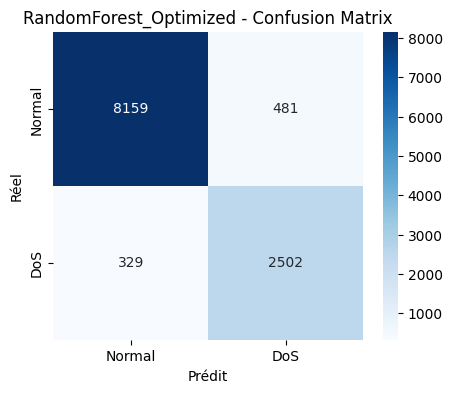

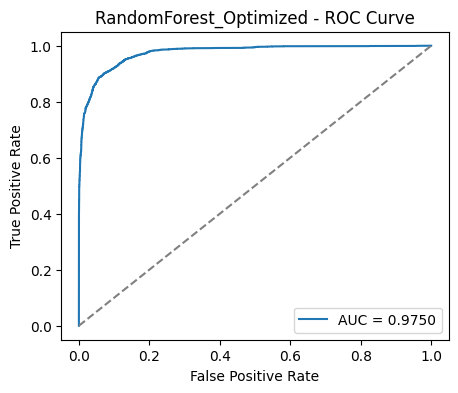


===== XGBoost_Optimized =====
              precision    recall  f1-score   support

           0     0.9729    0.9428    0.9576      8640
           1     0.8405    0.9198    0.8784      2831

    accuracy                         0.9371     11471
   macro avg     0.9067    0.9313    0.9180     11471
weighted avg     0.9402    0.9371    0.9381     11471



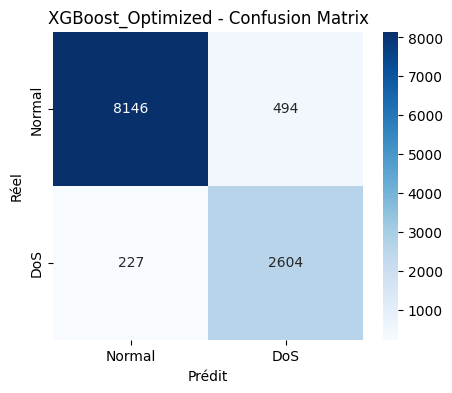

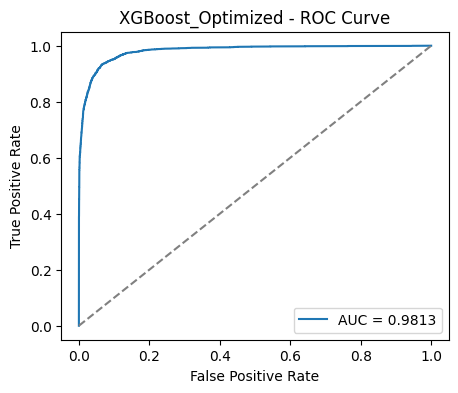


===== SVM =====
              precision    recall  f1-score   support

           0     0.9139    0.9605    0.9366      8640
           1     0.8573    0.7238    0.7849      2831

    accuracy                         0.9021     11471
   macro avg     0.8856    0.8422    0.8608     11471
weighted avg     0.8999    0.9021    0.8992     11471



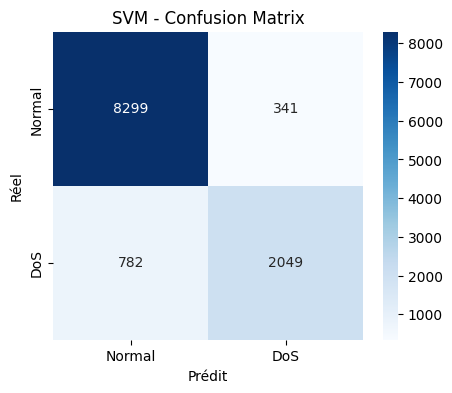

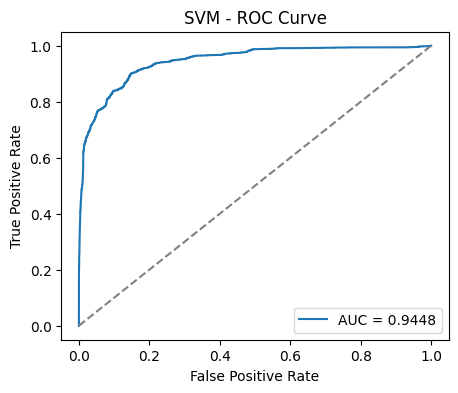

In [30]:
results = []

for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    print(classification_report(y_test, y_pred, digits=4))
    
    #  Stockage métriques
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","DoS"], yticklabels=["Normal","DoS"])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.show()
    
    #  Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.title(f"{name} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()



<div style="background-color: #fff8e1; border-left: 6px solid #ffa500; padding: 12px; border-radius: 10px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #333333; line-height: 1.6; margin-bottom: 15px;">
  <strong>💡 Seuil de classification :</strong> Les probabilités prédites par chaque modèle sont converties en classes binaires avec un seuil de 0,5 : ≥0,5 = attaque (1), <0,5 = normal (0). Ce seuil peut être ajusté pour favoriser la détection des attaques minoritaires.
</div>


<h3 style="color:#003366; border-bottom:3px solid #3399ff; padding-bottom:6px; font-family:Arial, sans-serif;">
🔹 Phase 5 – Évaluation et rapport
</h3>




In [31]:
print("\n===== RÉSULTATS FINAUX =====")
print(pd.DataFrame(results))


===== RÉSULTATS FINAUX =====
                    Model  Accuracy  Precision    Recall        F1   ROC-AUC
0  RandomForest_Optimized  0.929387   0.838753  0.883787  0.860681  0.974998
1       XGBoost_Optimized  0.937146   0.840542  0.919816  0.878394  0.981337
2                     SVM  0.902101   0.857322  0.723773  0.784907  0.944772



<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span>Vérification de overfitting</h3>







In [32]:
from sklearn.metrics import f1_score, roc_auc_score

for name, model in models.items():
    print(f"\n===== {name} - Overfitting check =====")
    
    # Prédiction train
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_train_pred = (y_train_proba >= 0.5).astype(int)
    
    # Metrics train
    f1_train = f1_score(y_train, y_train_pred)
    roc_train = roc_auc_score(y_train, y_train_proba)
    
    # Prédiction test
    y_test_proba = model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_proba >= 0.5).astype(int)
    
    f1_test = f1_score(y_test, y_test_pred)
    roc_test = roc_auc_score(y_test, y_test_proba)
    
    print(f"F1 train: {f1_train:.4f} | F1 test: {f1_test:.4f}")
    print(f"ROC-AUC train: {roc_train:.4f} | ROC-AUC test: {roc_test:.4f}")



===== RandomForest_Optimized - Overfitting check =====
F1 train: 0.8649 | F1 test: 0.8607
ROC-AUC train: 0.9760 | ROC-AUC test: 0.9750

===== XGBoost_Optimized - Overfitting check =====
F1 train: 0.8833 | F1 test: 0.8784
ROC-AUC train: 0.9819 | ROC-AUC test: 0.9813

===== SVM - Overfitting check =====
F1 train: 0.7883 | F1 test: 0.7849
ROC-AUC train: 0.9458 | ROC-AUC test: 0.9448



<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span>Vérification de fuite de données (data leakage)</h3>







In [33]:
print("Train windows:", train_raw['window'].min(), "-", train_raw['window'].max())
print("Test windows :", test_raw['window'].min(), "-", test_raw['window'].max())


Train windows: 2025-01-16 15:58:25+00:00 - 2025-09-10 02:09:39+00:00
Test windows : 2025-01-16 15:58:24+00:00 - 2025-09-10 02:09:37+00:00


Les dates semblent se chevaucher légèrement entre train et test.  
Pour vérifier s’il y a vraiment un chevauchement, on peut calculer l’intersection des fenêtres :

In [34]:
print("Overlap:", np.intersect1d(train_raw['window'], test_raw['window']))


Overlap: []


<div style="background-color: #e6ffed; border-left: 6px solid #28a745; padding: 20px 25px; border-radius: 12px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #145214;box-shadow: 3px 3px 12px rgba(0,0,0,0.1); line-height: 1.6; font-size: 16px; margin-bottom: 15px;">
<strong>✅ </strong> Aucune fenêtre n’est partagée entre train et test (<strong>Overlap = []</strong>) → pas de fuite de données.
</div>



<h3 style="color: #1565c0;  padding-bottom: 5px;"><span style="color:#3399ff; margin-right:8px;">✦</span>Vérification de features suspectes</h3>







In [35]:
corr = train_feat.corr()['target_max'].sort_values(ascending=False)
print(corr.head(10))


target_max                         1.000000
time_since_last_mean               0.268893
time_since_last_max                0.226808
ip_concentration                   0.034920
is_string_mean                     0.005719
msg_count_per_ip_in_window_mean    0.003834
is_numeric_mean                   -0.000019
iat_median                        -0.001869
iat_mean                          -0.002389
iat_std                           -0.004763
Name: target_max, dtype: float64


<div style="background-color: #e6ffed; border-left: 6px solid #28a745; padding: 15px 20px; border-radius: 10px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; color: #145214; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); line-height: 1.5; font-size: 15px; margin-bottom: 15px;">
- <strong>target_max = 1</strong> → normal<br>
- Les autres features ont très faible corrélation avec la target, sauf <strong>time_since_last_mean</strong> et <strong>time_since_last_max</strong> (modérée).<br>
✅ pas de feature “tricheuse” qui pourrait provoquer une fuite de données.
</div>


<h3 style="color:#003366; border-bottom:3px solid #3399ff; padding-bottom:6px; font-family:Arial, sans-serif;">
🔹 Deep learning
</h3>




**Normalisation et création de séquences**

In [36]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Séquences pour LSTM
seq_len = 5

def create_sequences_tf(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len + 1):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len-1])  # target de la dernière fenêtre
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences_tf(X_train_scaled, y_train, seq_len)
X_test_seq, y_test_seq   = create_sequences_tf(X_test_scaled, y_test, seq_len)

print("X_train_seq shape:", X_train_seq.shape)  # (n_samples, seq_len, n_features)


C:\Users\hp\AppData\Local\Temp\ipykernel_2684\3781988565.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_seq.append(y[i+seq_len-1])  # target de la dernière fenêtre


X_train_seq shape: (45878, 5, 15)


**Définition du modèle LSTM**

In [37]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

n_features = X_train_seq.shape[2]

model = Sequential([
    LSTM(64, input_shape=(seq_len, n_features)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # sortie binaire
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          20,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

**Entraînement**

In [38]:
history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=10,
    batch_size=64
)


Epoch 1/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9051 - loss: 0.2537 - val_accuracy: 0.9495 - val_loss: 0.1330
Epoch 2/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9525 - loss: 0.1278 - val_accuracy: 0.9576 - val_loss: 0.1108
Epoch 3/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9630 - loss: 0.1026 - val_accuracy: 0.9605 - val_loss: 0.1015
Epoch 4/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9670 - loss: 0.0898 - val_accuracy: 0.9688 - val_loss: 0.0867
Epoch 5/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9710 - loss: 0.0795 - val_accuracy: 0.9673 - val_loss: 0.0896
Epoch 6/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9737 - loss: 0.0703 - val_accuracy: 0.9615 - val_loss: 0.1008
Epoch 7/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9767 - loss: 0.0641 - val_accuracy: 0.9715 - val_loss: 0.0771
Epoch 8/10
717/717 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9789 - loss: 0.0578 - val_accuracy: 0.

**Évaluation**

In [39]:
y_pred_prob = model.predict(X_test_seq)
y_pred = (y_pred_prob >= 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_seq, y_pred))
print(confusion_matrix(y_test_seq, y_pred))


359/359 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      8640
           1       0.95      0.95      0.95      2827

    accuracy                           0.98     11467
   macro avg       0.97      0.97      0.97     11467
weighted avg       0.98      0.98      0.98     11467

[[8502  138]
 [ 128 2699]]


**Prédiction sur train et test**

In [42]:
# Prédiction probabilités
y_train_prob = model.predict(X_train_seq)
y_test_prob  = model.predict(X_test_seq)

# Conversion en classes binaires (seuil = 0.5)
y_train_pred = (y_train_prob >= 0.5).astype(int)
y_test_pred  = (y_test_prob >= 0.5).astype(int)


1434/1434 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
359/359 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


**Classification report et confusion matrix**

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score

# Train
print("=== Train ===")
print(classification_report(y_train_seq, y_train_pred))
print("Confusion matrix:\n", confusion_matrix(y_train_seq, y_train_pred))

# Test
print("\n=== Test ===")
print(classification_report(y_test_seq, y_test_pred))
print("Confusion matrix:\n", confusion_matrix(y_test_seq, y_test_pred))


=== Train ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     34560
           1       0.98      0.96      0.97     11318

    accuracy                           0.99     45878
   macro avg       0.98      0.98      0.98     45878
weighted avg       0.99      0.99      0.99     45878

Confusion matrix:
 [[34340   220]
 [  429 10889]]

=== Test ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      8640
           1       0.95      0.95      0.95      2827

    accuracy                           0.98     11467
   macro avg       0.97      0.97      0.97     11467
weighted avg       0.98      0.98      0.98     11467

Confusion matrix:
 [[8502  138]
 [ 128 2699]]


**F1-score et ROC-AUC pour overfitting**

In [44]:
f1_train = f1_score(y_train_seq, y_train_pred)
f1_test  = f1_score(y_test_seq, y_test_pred)
roc_train = roc_auc_score(y_train_seq, y_train_prob)
roc_test  = roc_auc_score(y_test_seq, y_test_prob)

print(f"F1-score train: {f1_train:.4f} | test: {f1_test:.4f}")
print(f"ROC-AUC train: {roc_train:.4f} | test: {roc_test:.4f}")


F1-score train: 0.9711 | test: 0.9530
ROC-AUC train: 0.9981 | test: 0.9956


**Courbes d’apprentissage**

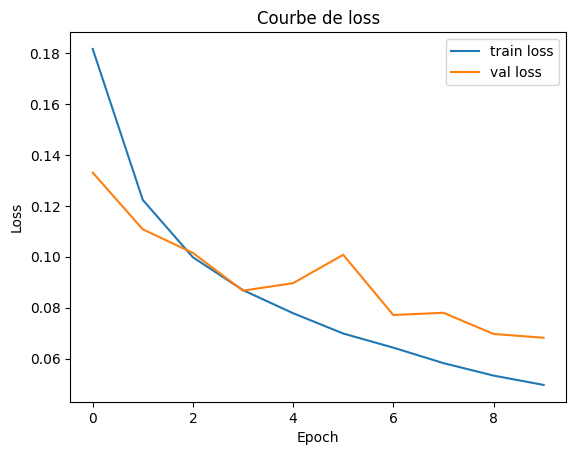

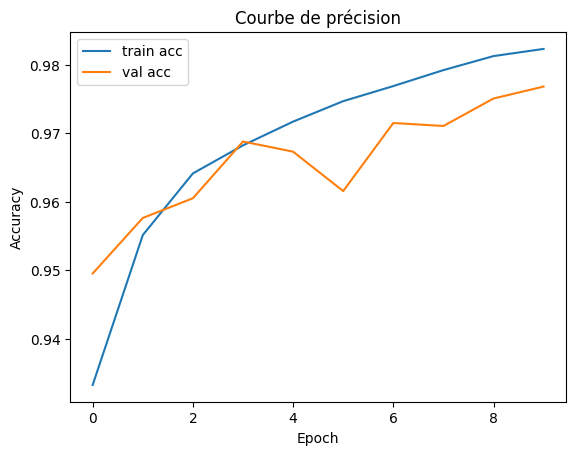

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title("Courbe de loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title("Courbe de précision")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()




### 1️⃣ Courbe de loss

**Observations :**

* **Train loss** : diminue de façon régulière de ~0.18 à ~0.05 → le modèle apprend correctement.
* **Validation loss** : commence plus bas (~0.13), descend rapidement jusqu’à ~0.09, puis fluctue légèrement.
* Les fluctuations mineures de la validation loss après l’epoch 4–5 sont normales et indiquent que le modèle s’ajuste sur des séquences un peu plus complexes.
* **Pas de divergence claire** entre train et validation → **pas de surapprentissage majeur**.

**Conclusion :**
Le modèle converge bien. La petite différence train/val est normale pour du Deep Learning sur séries temporelles.



### 2️⃣ Courbe de précision (accuracy)

**Observations :**

* L’**accuracy d’entraînement** commence autour de 0.93 et monte régulièrement jusqu’à ~0.98–0.985.
* L’**accuracy de validation** suit de très près, oscillant légèrement autour de 0.96–0.978.
* Les petites oscillations sur la validation sont normales et peuvent être dues à :

  * La taille des batches (64)
  * La séquence de données temporelles
  * La proportion de la classe minoritaire (DoS)

**Conclusion :**

* Les deux courbes montent ensemble, ce qui montre une **bonne généralisation**.
* Aucune divergence → **pas de surapprentissage**.
* Les valeurs finales (~0.98 train, ~0.975 val) indiquent une excellente performance.

